In [1]:
%matplotlib ipympl
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qutip import *
from IPython.display import Image, display, Math

In [2]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

### Lindblad functions

In [3]:
 def Liouvillian(H, gamma_k, L_k):
    
     I = np.eye(H.shape[0])  #creo matrice identità delle dimensioni adatte
     super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))  #Dissipatore di Lindblad
    
     for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))

     return super_L


In [4]:
def Lindblad_evo(rho, H, gamma_k, L_k, times, method="expm", vectorized=True):
    """
    Evolution of the density matrux with the Linblad Eq.
    
    Method: "U" -> propagator = expm(super_L * dt) (needs L_k as NumPy array)
            "diagonal" -> diagonalizzation of the super-op. (needs L_k as NumPy array )
            "qutip" -> using mesolve from QuTiP (needs L_k as Qobj)
    Vectorized: True/False to choose the output format
    
    Output:
            - if vectorized=True → array (N^2, Nt)
            - if vectorized=False → array (Nt, N_site, N_site)
       
    """
    N_shape = H.shape[0]
    dt = times[1] - times[0]
    
    # ===============================
    #   EXPM & DIAGONAL METHODS
    # ===============================
    if method in ["expm", "diagonal"]:
        # Converts Qobj in NumPy array 
        L_k_num = [L.full() if hasattr(L, "full") else np.array(L) for L in L_k]
        H_num = H.full() if hasattr(H, "full") else np.array(H)
        rho_num = rho.full() if hasattr(rho, "full") else np.array(rho)
        
        # Build up of the Lindbladian
        super_L = Liouvillian(H_num, gamma_k, L_k_num)
        
        # Vectorized intial state
        rho_vec = rho_num.reshape(N_shape*N_shape)
        
        # Result array inizialized
        rho_vec_list = np.zeros((N_shape*N_shape, len(times)), dtype=complex)
        rho_vec_list[:, 0] = rho_vec
        
        # Time Propagator
        if method == "expm":
            super_U = expm(super_L * dt)
            
            # Evolution
            for i in range(1, len(times)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output
            if vectorized:
                return rho_vec_list  # (N_shape^2, Nt)
            else:
                return rho_vec_list.T.reshape(len(times), N_shape, N_shape)  # (Nt, N_shape, N_shape)
                
        elif method == "diagonal":             #carefull, dt could be not homogneous, so calculate it in every loop in i
            #Diagobalization of the Super-Op.
            W, V = np.linalg.eig(super_L)
            Vinv = np.linalg.inv(V)
            # Converts in NumPy array
            W = np.array(W)  #Eigenenergies
            V = np.array(V)  #Eigenvectors
            Vinv = np.array(Vinv)
            
            # Build up of the Diagonal Lindbladian
            U_diag = np.diag(np.exp(W * dt))
            super_U = U_diag

            # Initial state in diagonal basis
            rho_vec_list_diagonal = np.zeros((rho_vec_list.shape[0], len(times)), dtype=complex)
            rho_vec_list_diagonal[:, 0] = Vinv @ rho_vec_list[:, 0]
            
            # Evolution
            for i in range(1, len(times)):
                rho_vec_list_diagonal[:, i] = super_U @ rho_vec_list_diagonal[:, i - 1]

                rho_vec_list[:, i] = V @ rho_vec_list_diagonal[:, i]
                
            # Output with Eigenenergies & Eigenvectors (as NumPy array)
            if vectorized:
                return rho_vec_list, V, W  
            else:
                return rho_vec_list.T.reshape(len(times), N_shape, N_shape), V, W  
    
    # ===============================
    #   QUTIP METHOD
    # ===============================
    elif method == "qutip":
        H_qobj = Qobj(H) if not hasattr(H, "full") else H
        rho_qobj = Qobj(rho) if not hasattr(rho, "full") else rho
        
        # Build up of the collapse operators
        c_ops = []
        for g, L in zip(gamma_k, L_k):
            if g != 0:
                L_qobj = L if hasattr(L, "full") else Qobj(L)
                c_ops.append(np.sqrt(g) * L_qobj)
        
        # Evolution with mesolve
        result = mesolve(H_qobj, rho_qobj, times, c_ops=c_ops, options={"store_states": True}, )
        
        # Converts the QuTiP eigenstates in vectorized NumPy array.
        rho_vec_list = np.zeros((N_site*N_site, len(times)), dtype=complex)
        for i, rho_t in enumerate(result.states):
            rho_vec_list[:, i] = rho_t.full().reshape(N_site*N_site)
        
        # Output
        if vectorized:
            return rho_vec_list
        else:
            return rho_vec_list.T.reshape(len(times), N_site, N_site)
    
    else:
        raise ValueError("Set 'expm', 'diagonal' or 'qutip'.")

### Collisional Method functions

In [5]:
def system_Hamiltonian(N_site, E, V_pot, mode="complete"):
    
    # =========================
    # Only Excited States Basis
    # =========================
    if mode == "exc":   
        H_sys = np.zeros((N_site, N_site), dtype=complex)
        for i in range(N_site):
            H_sys[i, i] = E[i]
        for i in range(N_site):
            for j in range(N_site):
                if i != j:
                    H_sys[i, j] = V_pot
        return H_sys
        
    # ==============
    # Complete Basis 
    # ==============    
    elif mode == "complete":   
        H_sys = np.zeros((2**N_site, 2**N_site), dtype='complex')
        
        for i in range(N_site):
            H_i = (E[i]/2) * (tensor(identity(2**i), identity(2)-sigmaz(), identity(2**(N_site-i-1)))) # g states have 0 energy and the e sites have all the energy
            #H_i = (E[i]/2) * tensor(identity(2**i), sigmaz(), identity(2**(N_site-i-1)))   # To be the same as eq II.18, where g and e state has the sameenergy but with different sign, as like the DE between the two states is equal to excoted state energy
            
            H_sys += H_i.full()

            for j in range(i+1, N_site):
               H_ij = V_pot/2 * (tensor(identity(2**i), sigmax(), identity(2**(j-i-1)), sigmax(), identity(2**(N_site-j-1))) + tensor(identity(2**i), sigmay(), identity(2**(j-i-1)), sigmay(), identity(2**(N_site-j-1))))
               H_sys += H_ij.full()
        return H_sys

    else:
        raise ValueError("mode has to be 'complete' or 'exc'")


In [6]:
def interaction_Hamiltonian_N_ancillas(N_site, c_list):   #Hamiltonian of interaction with N different ancillas, one for every site of the system

    H_int = 0   #inizialization

    for j in range(N_site):
  
        op_list = [identity(2) for _ in range(2 * N_site)]  #list of identity to be fill with the operator sigmaz & sigmax; 2N idensitty, N for the system and N fo the ancillas
        
        op_list[j] = sigmaz()      # Acts on the j site
        op_list[N_site + j] = sigmax()  # Acts on the j ancilla, with index N + j
        
        H_term = c_list[j] * tensor(op_list)  # tensor product between the element of the list
        H_int += H_term

    return H_int


In [7]:
def hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete"):
    """
    Generation of 3 Hamiltonians for the collision model with N ancillas:
        - H_system : system Hamiltonian
        - H_collision : interaction Hamiltonian with N ancillas
        - H_tot : complete Hamiltonian (system + collision)
    
    Method : - complete : both excited and ground states
             - excited : only excited states
    """
    
    if method == "complete":
        # ==============
        # Complete Basis 
        # ==============

        H_system_np = system_Hamiltonian(N_site, E, V_pot, mode="complete")
        H_system = Qobj(H_system_np, dims=[[2]*N_site, [2]*N_site])
        
        H_collision = interaction_Hamiltonian_N_ancillas(N_site, c_list)
        
        Id_ancillas = tensor([identity(2) for _ in range(N_site)])
        H_tot = tensor(H_system, Id_ancillas) + H_collision
        
        return H_system, H_collision, H_tot
        
    elif method == "excited":        #DA RIVEDERE COME DEFINISCO L'OPERATORE DI COLLSIONE
        # =========================
        # Only Excited States Basis
        # =========================
        
         H_system = Qobj(system_Hamiltonian(N_site, E, V_pot, mode="exc"))
        
         H_collision = 0
         for j in range(N_site):
            diag_vals = np.ones(N_site)
            diag_vals[j] = -1 
            Z_sys_j = Qobj(np.diag(diag_vals))
            
            anc_ops = [identity(2) for _ in range(N_site)]
            anc_ops[j] = sigmax()
            X_anc_j = tensor(anc_ops)
            
            H_collision += c_list[j] * tensor(Z_sys_j, X_anc_j)
        
         Id_ancillas = tensor([identity(2) for _ in range(N_site)])
         H_tot = tensor(H_system, Id_ancillas) + H_collision
        
         return H_system, H_collision, H_tot
        
    else:
         raise ValueError("method has to be 'complete' or 'excited'")

In [8]:
def evolution_operator(H, dt, backend='numpy', method='expm', hermitian=True):
    """
    Returns the evolution operator U = exp(-i H dt)
    using NumPy, QuTiP, or analytic diagonalization.
    """
    # Converts in Numpy array
    if backend == 'numpy':
        if isinstance(H, Qobj):
            H_np = H.full()
        else:
            H_np = np.array(H, dtype=complex)
    # Converts in QuTip array
    elif backend == 'qutip':
        if not isinstance(H, Qobj):
            H_qt = Qobj(np.array(H, dtype=complex))
        else:
            H_qt = H
    else:
        raise ValueError("backend must be 'numpy' or 'qutip'")
    
    # =====================
    # EXPONENTIAL with EXPM
    # =====================
    if method == 'expm':
        if backend == 'numpy':
            U = expm(-1j * H_np * dt)
            return U
        elif backend == 'qutip':
            original_dims = H_qt.dims
            U = (-1j * H_qt * dt).expm()
            U.dims = original_dims
            return U
    
    # ===============
    # DIAGONALIZATION
    # ===============
    elif method == 'diagonalization':
        if backend == 'numpy':
            if hermitian:
                w, v = np.linalg.eigh(H_np)
                vinv = v.conj().T
            else:
                w, v = np.linalg.eig(H_np) 
                vinv = np.linalg.inv(v)
                
            U_diag = np.diag(np.exp(-1j * w * dt))
            U = v @ U_diag @ vinv
            return U, U_diag, w, v
        
        elif backend == 'qutip':
            original_dims = H_qt.dims
            
            if hermitian:
                w, v = np.linalg.eigh(H_qt.full())
                vinv = v.conj().T
            else:
                w, v = np.linalg.eig(H_qt.full()) 
                vinv = np.linalg.inv(v)
                
            U_diag_np = np.diag(np.exp(-1j * w * dt))
            U_np = v @ U_diag_np @ vinv 
            
            U_diag = Qobj(U_diag_np, dims=original_dims)
            U = Qobj(U_np, dims=original_dims)  
            
        return U, U_diag, w, v
    else:
        raise ValueError("method must be 'expm' or 'diagonalization'")


### Case of Study : Exciton Dimer

In [9]:
# System's Parameters
N_site = 2            # Number of sites
V_pot = 1.0           # Hopping Potential
E = 1.5 + np.random.randn(N_site)*0.1     #random inizialization of the system energies

# Time Evolution Parameters
dt = 0.01          # Time step
tf = 50.0          # Final Time
steps = int(tf / dt) # Number of steps
times = np.linspace(0, tf, steps)

# Dephasing Parameter (come in MATLAB)
g_deph = 0.1       # Gamma rate
# Scaling for the collsional algorithm c = sqrt(gamma / 4dt)
c_CM = np.sqrt(g_deph / (4 * dt)) 
c_list = [c_CM, c_CM] # same Coupling for the 2 sites

array_to_latex(E)

<IPython.core.display.Math object>

In [10]:
# Initial wave function and density matrix
# System
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho_sys = ket2dm(psi_sys_initial)

# Ancilla
rho_anc_single = ket2dm(basis(2, 0)) # Pure state |0><0| for a singe ancilla
rho_anc_all = tensor([rho_anc_single for _ in range(N_site)]) #for N ancilla


In [11]:
# Hamiltonian & U
# Base: |00>, |10>, |01>, |11>
H_site, H_coll, H_tot = hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete")
U_tot, U_diag, w, V = evolution_operator(H_tot, dt, backend='numpy', method='diagonalization') #calculated only 1 time out of the cycle
U_tot = Qobj(U_tot, dims=H_tot.dims); U_diag = Qobj(U_diag, dims=H_tot.dims); U_diag_dag = U_diag.dag(); V = Qobj(V, dims=H_tot.dims); V_dag = V.dag() 

In [12]:
# Projector for the extraction from the rho
P0 = (identity(2) + sigmaz()) / 2  # projector on |0>
P1 = (identity(2) - sigmaz()) / 2  # projector su |1>

P_00 = tensor(P0, P0) # |00><00|
P_01 = tensor(P0, P1) # |01><01|
P_10 = tensor(P1, P0) # |10><10|
P_11 = tensor(P1, P1) # |11><11|

#### Evolution with $ U_{complete} $ and then trace on the ancilla

In [13]:
# Array to store the results of the evolution dimension time_step x 1
pops_1_complete = [] #population on site 1
pops_2_complete = [] #population on site 2

#initial state
pops_1_complete.append(expect(P_10, rho_sys))
pops_2_complete.append(expect(P_01, rho_sys)) 

# Time Evolution
for t in range (len(times)):

    # 1 : expansion in the system-ancilla space by tensor product
    rho_tot = tensor(rho_sys, rho_anc_all)   # I always use ancillas in their initial state! already resetted 
    rho_diag = V_dag * rho_tot * V  #diagonal form for the evolution 
    
    # 2 : Unitary evolution of the total rho
    rho_diag = U_diag * rho_diag * U_diag_dag
    rho_tot = V * rho_diag * V_dag
    
    # 3 : Partial Trace on the ancilla's degree of freedom
    rho_sys = rho_tot.ptrace([0,1]) 

    # 4 : Store the result of the population
    pops_1_complete.append(expect(P_10, rho_sys))
    pops_2_complete.append(expect(P_01, rho_sys)) 

#### Single trajectory

In [25]:
# Hamiltonian & System Wave Function
H_system = system_Hamiltonian(N_site, E, V_pot, mode="complete")
U_site, U_diag_site, w, V = evolution_operator(H_system, dt, backend='qutip', method='diagonalization', hermitian=True)
U_site.dims = H_site.dims 

psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
#array_to_latex(psi_sys_initial.full(), real=True)

In [36]:
# Evolution of the Wave Function
jump_probabilities = [np.sin(c * dt)**2 for c in c_list]   #probability to apply sigmaz to psi
N_traj = 1000  #number of trajectories repeted
count = np.zeros(N_traj)
pop_N_traj = np.zeros((N_site, steps, N_traj))  #array to store the population of every site at every step of evolution for every trajectories
# Costruction of the sigmaz operator for every site
Sz_ops = []
for idx in range(N_site):
    ops = [qeye(2) for _ in range(N_site)]
    ops[idx] = sigmaz()  # Sigmaz solo sul sito idx
    Sz_op = tensor(ops)
    Sz_ops.append(Sz_op)
    
# Inizialization
pop_site_1_initial = expect(P_10, psi_sys_initial)
pop_site_2_initial = expect(P_01, psi_sys_initial)
pop_N_traj[0,0,:] = pop_site_1_initial
pop_N_traj[1,0,:] = pop_site_2_initial
# Evolution for different Trajectories 
for traj in range (N_traj):
    # 1 reset initial wf |01>
    psi = psi_sys_initial   
    # 2 Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
        
        psi = U_site * psi   # Evolution of wf with H_site
        
        collision_occurred = False  # Flag per tracciare se c'è stata almeno una collisione
        
        # 3 Defining the condition of the Monte Carlo - Jump for every site
        for site_index in range(N_site):
            r_site = np.random.rand() # Random number between 0 & 1
            
            if r_site < jump_probabilities[site_index]:
                psi = Sz_ops[site_index] * psi   # apply Sigmaz 
                psi = psi / psi.norm()   #{no renormalization, Sigmaz unitary}
                collision_occurred = True 
        
        if not collision_occurred:
            count[traj] = count[traj] + 1
        
        # 4 Expectation Value
        pop_site_1 = expect(P_10, psi)
        pop_site_2 = expect(P_01, psi)
        pop_N_traj[0, step, traj] = pop_site_1
        pop_N_traj[1, step, traj] = pop_site_2
# Average value of different trajectories
average_pop = np.mean(pop_N_traj, axis=2)     

In [37]:
pop_N_traj.shape

(2, 5000, 1000)

In [38]:
sum_001 = 0.0
for x in range (0, len(count)):
    sum_001 += count[x]
media_001 = sum_001 / len(times) 


for x in range (0, len(count)):
    count[x] /= steps
print(count)
print(media_001)

[0.9996 0.9992 0.9998 0.9992 0.9994 0.9994 0.9988 0.9996 0.9992 0.9994
 0.9994 0.9992 0.9998 0.999  0.999  0.9994 0.9996 0.999  0.9992 0.9996
 0.9992 0.9994 0.999  0.9994 0.9992 0.9996 0.9994 0.998  0.9996 0.9988
 0.9994 0.9994 0.9998 0.9992 0.9996 0.9988 0.9992 0.9992 0.999  0.999
 0.9992 0.9996 0.9994 0.9992 0.9996 0.9996 0.9988 0.999  0.9998 0.9996
 0.9992 0.9998 0.9988 0.9996 0.9998 0.9992 0.9996 0.999  0.9996 0.9996
 0.9998 0.9996 0.9988 0.9996 0.9994 0.9992 0.9994 0.9996 0.9994 0.9988
 0.9992 0.9994 0.9994 0.9996 0.9992 0.9986 0.9998 0.9992 0.9998 0.9994
 0.999  0.9994 0.9994 0.9998 0.9994 0.9992 0.9996 0.9994 0.9992 0.9996
 0.9994 0.9996 0.9992 0.9994 0.9998 0.9992 0.999  0.9996 0.9992 0.9994
 0.9994 0.9996 0.9994 0.9994 0.9996 0.9988 0.9994 0.9992 0.999  0.9996
 0.9992 0.9994 0.9994 0.9994 0.9996 0.999  0.999  0.999  0.9994 0.9998
 0.9986 0.9998 0.9998 0.9994 0.9994 0.9988 0.9994 0.9994 0.9992 0.999
 0.9992 0.9994 0.9996 0.9994 0.9992 0.9996 0.9996 0.9988 0.9996 0.9988
 0.9986 

#### Isolated system

In [39]:
# Isolated system
pop_N_traj_isolated = np.zeros((N_site, steps, N_traj))
# Inizialization
pop_site_1_initial = expect(P_10, psi_sys_initial)
pop_site_2_initial = expect(P_01, psi_sys_initial)

pop_N_traj_isolated [0,0,:] = pop_site_1_initial
pop_N_traj_isolated [1,0,:] = pop_site_2_initial

# Evolution for different Trajectories 
for traj in range (N_traj):

    psi = psi_sys_initial   #reset initial wf |01>

    # Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
        
        psi = U_site * psi   # Evolution of wf with H_site
               
        pop_site_1 = expect(P_10, psi)
        pop_site_2 = expect(P_01, psi)

        pop_N_traj_isolated[0, step, traj] = pop_site_1
        pop_N_traj_isolated [1, step, traj] = pop_site_2

# Average value of different trajectories
average_pop_isolated = np.mean(pop_N_traj_isolated, axis=2)  

#### Lindbald

In [40]:
H = system_Hamiltonian(N_site, E, V_pot, mode="complete")
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho = ket2dm(psi_sys_initial)
#Jump Oerator
L_1 = tensor(sigmaz(), qeye(2))
L_2 = tensor(qeye(2), sigmaz())

L_k = [L_1.full(), L_2.full()]

#Rates
gamma = g_deph * 0.25
gamma_k = [gamma, gamma]

Super_L = Liouvillian(H, gamma_k, L_k)
rho_list_lindblad, V, W = Lindblad_evo(rho, H, gamma_k, L_k, times, method="diagonal", vectorized=False)

### Plot
#### Average Evolution with trace on the ancillas

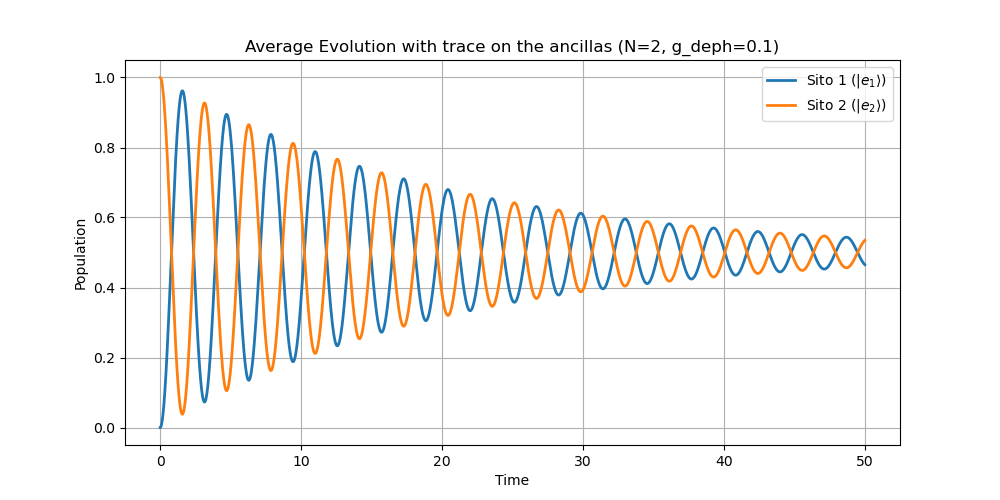

In [41]:
times_plot = np.linspace(0, tf + dt, steps + 1) # time for the plot

fig01, ax = plt.subplots(figsize=(10,5))
ax.plot(times_plot, pops_1_complete, label=r'Sito 1 ($|e_1\rangle$)', linewidth=2)
ax.plot(times_plot, pops_2_complete, label=r'Sito 2 ($|e_2\rangle$)', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title(f'Average Evolution with trace on the ancillas (N={N_site}, g_deph={g_deph})')
ax.legend()
ax.grid(True)
plt.show()


#### Single trajectory

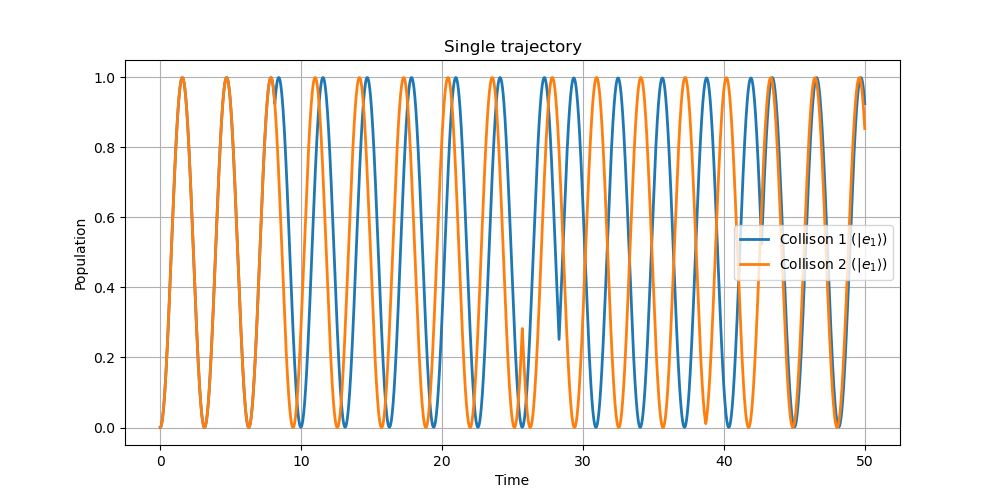

In [42]:
times_plot = np.linspace(0, tf + dt, steps) # time for the plot

fig02, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_plot, pop_N_traj[0, :, 1], label=r'Collison 1 ($|e_1\rangle$)', linewidth=2)
ax.plot(times_plot, pop_N_traj[0, :, 5], label=r'Collison 2 ($|e_1\rangle$)', linewidth=2)

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title( 'Single trajectory')
ax.legend()
ax.grid(True)

plt.show()

#### Single trajectory vs Average evolution

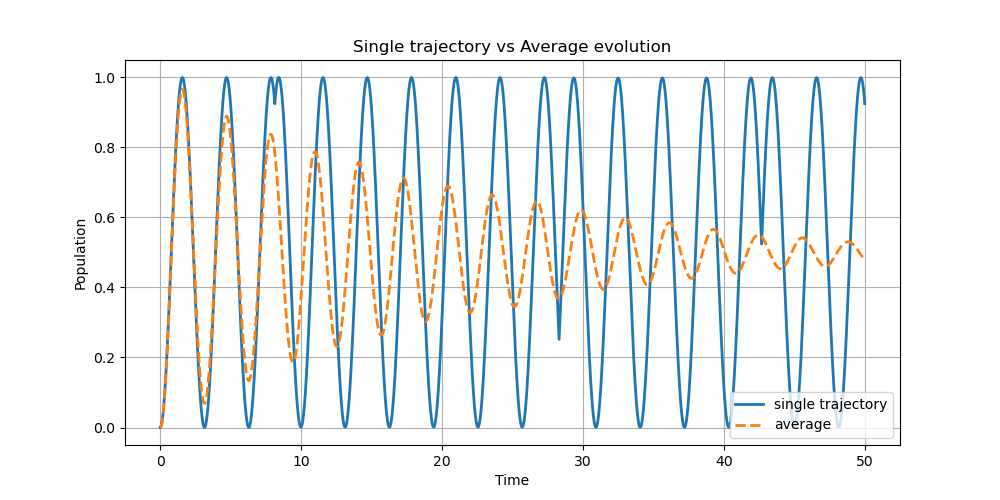

In [43]:
times_plot = np.linspace(0, tf + dt, steps) # time for the plot

fig03, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_plot, pop_N_traj[0, :, 1], label=r'single trajectory', linewidth=2)
ax.plot(times_plot, average_pop[0, :], label=r'average', linewidth=2, linestyle='--')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title( 'Single trajectory vs Average evolution')
ax.legend()
ax.grid(True)

plt.show()

#### Comparison Lindblad vs Average of N trajectories vs Trace on Ancilla 

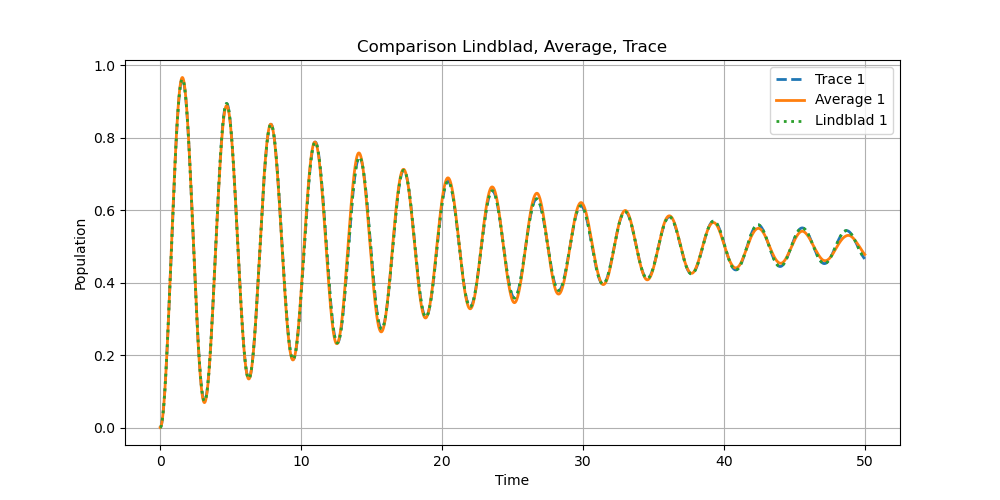

In [44]:
fig04, ax = plt.subplots(figsize=(10, 5))

ax.plot(times, pops_1_complete[:-1], label=r'Trace 1', linewidth=2, linestyle='--')  # Rimuovi ultimo elemento
ax.plot(times, average_pop[0, :], label=r'Average 1', linewidth=2)
ax.plot(times, np.real(rho_list_lindblad[:, 2, 2]), label=r'Lindblad 1', linewidth=2, linestyle=':')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title('Comparison Lindblad, Average, Trace')
ax.legend()
ax.grid(True)
plt.show()

#### Comparison single trajectory of Isolated system vs ollsional system 

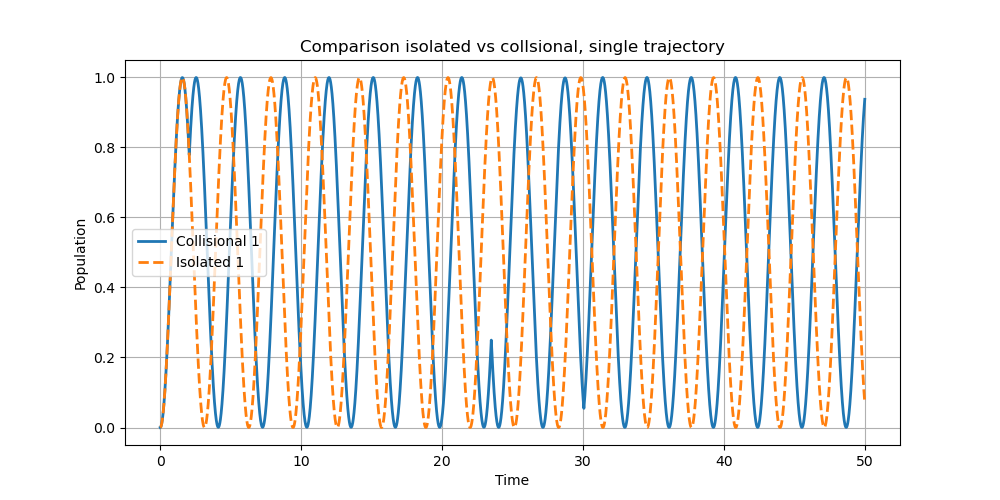

In [45]:
fig05, ax = plt.subplots(figsize=(10, 5))

ax.plot(times, pop_N_traj[0, :, 20], label=r'Collisional 1', linewidth=2) 
ax.plot(times, pop_N_traj_isolated[0, :, 20], label=r'Isolated 1', linewidth=2, linestyle='--')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title('Comparison isolated vs collsional, single trajectory')
ax.legend()
ax.grid(True)
plt.show()

## REDO for $ \Delta t = 0.05 $ 

In [46]:
# System's Parameters

# Time Evolution Parameters
dt = 0.05          # Time step
tf = 50.0          # Final Time
steps = int(tf / dt) # Number of steps
times = np.linspace(0, tf, steps)

# Dephasing Parameter (come in MATLAB)
g_deph = 0.1       # Gamma rate
# Scaling for the collsional algorithm c = sqrt(gamma / 4dt)
c_CM = np.sqrt(g_deph / (4 * dt)) 
c_list = [c_CM, c_CM] # same Coupling for the 2 sites

array_to_latex(E)
np.size(times)

<IPython.core.display.Math object>

1000

In [47]:
# Initial wave function and density matrix
# System
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho_sys = ket2dm(psi_sys_initial)

# Ancilla
rho_anc_single = ket2dm(basis(2, 0)) # Pure state |0><0| for a singe ancilla
rho_anc_all = tensor([rho_anc_single for _ in range(N_site)]) #for N ancilla


In [48]:
# Hamiltonian & U
# Base: |00>, |10>, |01>, |11>
H_site, H_coll, H_tot = hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete")
U_tot, U_diag, w, V = evolution_operator(H_tot, dt, backend='numpy', method='diagonalization') #calculated only 1 time out of the cycle
U_tot = Qobj(U_tot, dims=H_tot.dims); U_diag = Qobj(U_diag, dims=H_tot.dims); U_diag_dag = U_diag.dag(); V = Qobj(V, dims=H_tot.dims); V_dag = V.dag() 

#### Evolution with $ U_{complete} $ and then trace on the ancilla

In [49]:
# Array to store the results of the evolution dimension time_step x 1
pops_1_complete_005 = [] #population on site 1
pops_2_complete_005 = [] #population on site 2

#initial state
pops_1_complete_005.append(expect(P_10, rho_sys))
pops_2_complete_005.append(expect(P_01, rho_sys)) 

# Time Evolution
for t in range (len(times)):

    # 1 : expansion in the system-ancilla space by tensor product
    rho_tot = tensor(rho_sys, rho_anc_all)   # I always use ancillas in their initial state! already resetted 
    rho_diag = V_dag * rho_tot * V  #diagonal form for the evolution 
    
    # 2 : Unitary evolution of the total rho
    rho_diag = U_diag * rho_diag * U_diag_dag
    rho_tot = V * rho_diag * V_dag
    
    # 3 : Partial Trace on the ancilla's degree of freedom
    rho_sys = rho_tot.ptrace([0,1]) 

    # 4 : Store the result of the population
    pops_1_complete_005.append(expect(P_10, rho_sys))
    pops_2_complete_005.append(expect(P_01, rho_sys)) 

#### Single trajectory

In [50]:
# Hamiltonian & System Wave Function
H_system = system_Hamiltonian(N_site, E, V_pot, mode="complete")
U_site, U_diag_site, w, V = evolution_operator(H_system, dt, backend='qutip', method='diagonalization', hermitian=True)
U_site.dims = H_site.dims 

psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
#array_to_latex(psi_sys_initial.full(), real=True)

In [51]:
# Evolution of the Wave Function
jump_probabilities = [np.sin(c * dt)**2 for c in c_list]   #probability to apply sigmaz to psi
N_traj = 100  #number of trajectories repeted
count_005 = np.zeros(N_traj)
pop_N_traj_005 = np.zeros((N_site, steps, N_traj))  #array to store the population of every site at every step of evolution for every trajectories
# Costruction of the sigmaz operator for every site
Sz_ops = []
for idx in range(N_site):
    ops = [qeye(2) for _ in range(N_site)]
    ops[idx] = sigmaz()  # Sigmaz solo sul sito idx
    Sz_op = tensor(ops)
    Sz_ops.append(Sz_op)
    
# Inizialization
pop_site_1_initial = expect(P_10, psi_sys_initial)
pop_site_2_initial = expect(P_01, psi_sys_initial)
pop_N_traj_005[0,0,:] = pop_site_1_initial
pop_N_traj_005[1,0,:] = pop_site_2_initial
# Evolution for different Trajectories 
for traj in range (N_traj):
    # 1 reset initial wf |01>
    psi = psi_sys_initial   
    # 2 Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
        
        psi = U_site * psi   # Evolution of wf with H_site
        
        collision_occurred = False  # Flag per tracciare se c'è stata almeno una collisione
        
        # 3 Defining the condition of the Monte Carlo - Jump for every site
        for site_index in range(N_site):
            r_site = np.random.rand() # Random number between 0 & 1
            
            if r_site < jump_probabilities[site_index]:
                psi = Sz_ops[site_index] * psi   # apply Sigmaz 
                psi = psi / psi.norm()   #{no renormalization, Sigmaz unitary}
                collision_occurred = True 
        
        if not collision_occurred:
            count_005[traj] = count_005[traj] + 1
        
        # 4 Expectation Value
        pop_site_1 = expect(P_10, psi)
        pop_site_2 = expect(P_01, psi)
        pop_N_traj_005[0, step, traj] = pop_site_1
        pop_N_traj_005[1, step, traj] = pop_site_2
# Average value of different trajectories
average_pop_005 = np.mean(pop_N_traj_005, axis=2)   

In [52]:
sum_005 = 0.0
for x in range (0, len(count_005)):
    sum_005 += count_005[x]
media_005 = sum_005 / len(times) 


for x in range (0, len(count_005)):
    count_005[x] /= steps
print(count_005)
print(media_005)

[0.992 0.995 0.998 0.998 0.995 0.998 0.997 0.995 0.996 0.995 0.995 0.998
 0.996 0.993 0.996 0.997 0.994 0.999 0.997 0.999 0.995 0.995 0.998 0.996
 0.998 0.995 0.996 0.999 0.996 0.995 0.999 0.996 0.995 0.997 0.998 0.997
 0.998 0.996 0.996 0.996 0.996 0.996 0.999 0.997 0.995 0.999 0.997 0.998
 0.993 0.996 0.998 0.997 0.997 0.996 0.998 0.996 0.998 0.995 0.994 0.998
 0.997 0.996 0.997 0.995 0.996 0.996 0.999 0.997 0.999 0.998 0.994 0.996
 0.997 0.999 0.996 0.997 0.999 0.994 0.995 0.997 0.994 0.998 0.997 0.995
 0.997 0.996 0.996 0.996 0.996 0.996 0.998 0.999 0.997 0.995 0.994 0.999
 0.998 0.996 0.996 0.997]
99.651


#### Isolated system

In [53]:
# Isolated system
pop_N_traj_isolated_005 = np.zeros((N_site, steps, N_traj))
# Inizialization
pop_site_1_initial = expect(P_10, psi_sys_initial)
pop_site_2_initial = expect(P_01, psi_sys_initial)

pop_N_traj_isolated_005 [0,0,:] = pop_site_1_initial
pop_N_traj_isolated_005 [1,0,:] = pop_site_2_initial

# Evolution for different Trajectories 
for traj in range (N_traj):

    psi = psi_sys_initial   #reset initial wf |01>

    # Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
        
        psi = U_site * psi   # Evolution of wf with H_site
               
        pop_site_1 = expect(P_10, psi)
        pop_site_2 = expect(P_01, psi)

        pop_N_traj_isolated_005[0, step, traj] = pop_site_1
        pop_N_traj_isolated_005 [1, step, traj] = pop_site_2

# Average value of different trajectories
average_pop_isolated_005 = np.mean(pop_N_traj_isolated_005, axis=2)  

### Linblad

In [54]:
H = system_Hamiltonian(N_site, E, V_pot, mode="complete")
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho = ket2dm(psi_sys_initial)
#Jump Oerator
L_1 = tensor(sigmaz(), qeye(2))
L_2 = tensor(qeye(2), sigmaz())

L_k = [L_1.full(), L_2.full()]

#Rates
gamma = g_deph * 0.25
gamma_k = [gamma, gamma]

Super_L = Liouvillian(H, gamma_k, L_k)
rho_list_lindblad_005, V, W = Lindblad_evo(rho, H, gamma_k, L_k, times, method="diagonal", vectorized=False)

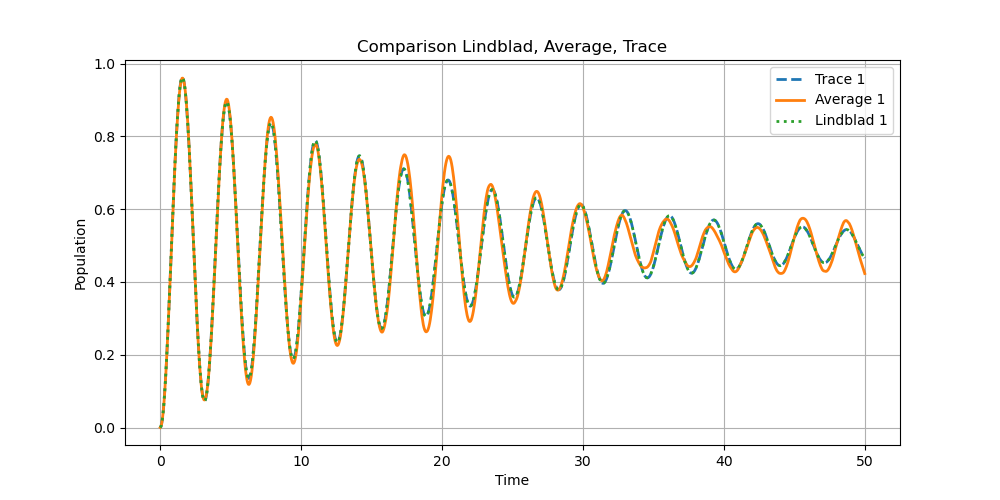

In [55]:
dt = 0.05          # Time step
tf = 50.0          # Final Time
steps = int(tf / dt) # Number of steps
times = np.linspace(0, tf, steps)

fig10, ax = plt.subplots(figsize=(10, 5))

ax.plot(times, pops_1_complete_005[:-1], label=r'Trace 1', linewidth=2, linestyle='--')  # Rimuovi ultimo elemento
ax.plot(times, average_pop_005[0, :], label=r'Average 1', linewidth=2)
ax.plot(times, np.real(rho_list_lindblad_005[:, 2, 2]), label=r'Lindblad 1', linewidth=2, linestyle=':')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title('Comparison Lindblad, Average, Trace')
ax.legend()
ax.grid(True)
plt.show()

# REDO

In [56]:
# System's Parameters

# Time Evolution Parameters
dt = 0.02          # Time step
tf = 50.0          # Final Time
steps = int(tf / dt) # Number of steps
times = np.linspace(0, tf, steps)

# Dephasing Parameter (come in MATLAB)
g_deph = 0.1       # Gamma rate
# Scaling for the collsional algorithm c = sqrt(gamma / 4dt)
c_CM = np.sqrt(g_deph / (4 * dt)) 
c_list = [c_CM, c_CM] # same Coupling for the 2 sites

array_to_latex(E)

<IPython.core.display.Math object>

In [57]:
# Initial wave function and density matrix
# System
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho_sys = ket2dm(psi_sys_initial)

# Ancilla
rho_anc_single = ket2dm(basis(2, 0)) # Pure state |0><0| for a singe ancilla
rho_anc_all = tensor([rho_anc_single for _ in range(N_site)]) #for N ancilla


In [58]:
# Hamiltonian & U
# Base: |00>, |10>, |01>, |11>
H_site, H_coll, H_tot = hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete")
U_tot, U_diag, w, V = evolution_operator(H_tot, dt, backend='numpy', method='diagonalization') #calculated only 1 time out of the cycle
U_tot = Qobj(U_tot, dims=H_tot.dims); U_diag = Qobj(U_diag, dims=H_tot.dims); U_diag_dag = U_diag.dag(); V = Qobj(V, dims=H_tot.dims); V_dag = V.dag() 

#### Evolution with $ U_{complete} $ and then trace on the ancilla

In [59]:
# Array to store the results of the evolution dimension time_step x 1
pops_1_complete_002 = [] #population on site 1
pops_2_complete_002 = [] #population on site 2

#initial state
pops_1_complete_002.append(expect(P_10, rho_sys))
pops_2_complete_002.append(expect(P_01, rho_sys)) 

# Time Evolution
for t in range (len(times)):

    # 1 : expansion in the system-ancilla space by tensor product
    rho_tot = tensor(rho_sys, rho_anc_all)   # I always use ancillas in their initial state! already resetted 
    rho_diag = V_dag * rho_tot * V  #diagonal form for the evolution 
    
    # 2 : Unitary evolution of the total rho
    rho_diag = U_diag * rho_diag * U_diag_dag
    rho_tot = V * rho_diag * V_dag
    
    # 3 : Partial Trace on the ancilla's degree of freedom
    rho_sys = rho_tot.ptrace([0,1]) 

    # 4 : Store the result of the population
    pops_1_complete_002.append(expect(P_10, rho_sys))
    pops_2_complete_002.append(expect(P_01, rho_sys)) 

#### Single trajectory

In [60]:
# Hamiltonian & System Wave Function
H_system = system_Hamiltonian(N_site, E, V_pot, mode="complete")
U_site, U_diag_site, w, V = evolution_operator(H_system, dt, backend='qutip', method='diagonalization', hermitian=True)
U_site.dims = H_site.dims 

psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
#array_to_latex(psi_sys_initial.full(), real=True)

In [61]:
# Evolution of the Wave Function
jump_probabilities = [np.sin(c * dt)**2 for c in c_list]   #probability to apply sigmaz to psi
N_traj = 100  #number of trajectories repeted
count_002 = np.zeros(N_traj)
pop_N_traj_002 = np.zeros((N_site, steps, N_traj))  #array to store the population of every site at every step of evolution for every trajectories
# Costruction of the sigmaz operator for every site
Sz_ops = []
for idx in range(N_site):
    ops = [qeye(2) for _ in range(N_site)]
    ops[idx] = sigmaz()  # Sigmaz solo sul sito idx
    Sz_op = tensor(ops)
    Sz_ops.append(Sz_op)
    
# Inizialization
pop_site_1_initial = expect(P_10, psi_sys_initial)
pop_site_2_initial = expect(P_01, psi_sys_initial)
pop_N_traj_005[0,0,:] = pop_site_1_initial
pop_N_traj_005[1,0,:] = pop_site_2_initial
# Evolution for different Trajectories 
for traj in range (N_traj):
    # 1 reset initial wf |01>
    psi = psi_sys_initial   
    # 2 Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
        
        psi = U_site * psi   # Evolution of wf with H_site
        
        collision_occurred = False  # Flag per tracciare se c'è stata almeno una collisione
        
        # 3 Defining the condition of the Monte Carlo - Jump for every site
        for site_index in range(N_site):
            r_site = np.random.rand() # Random number between 0 & 1
            
            if r_site < jump_probabilities[site_index]:
                psi = Sz_ops[site_index] * psi   # apply Sigmaz 
                psi = psi / psi.norm()   #{no renormalization, Sigmaz unitary}
                collision_occurred = True 
        
        if not collision_occurred:
            count_002[traj] = count_002[traj] + 1
        
        # 4 Expectation Value
        pop_site_1 = expect(P_10, psi)
        pop_site_2 = expect(P_01, psi)
        pop_N_traj_002[0, step, traj] = pop_site_1
        pop_N_traj_002[1, step, traj] = pop_site_2
# Average value of different trajectories
average_pop_002 = np.mean(pop_N_traj_002, axis=2)   

In [62]:
np.size(times)

2500

In [63]:
sum_002 = 0.0
for x in range (0, len(count_002)):
    sum_002 += count_002[x]
media_002 = sum_002 / len(times) 


for x in range (0, len(count_002)):
    count_002[x] /= steps
print(count_002)
print(media_002)


[0.9988 0.9988 0.9984 0.9984 0.9996 0.9984 0.9984 0.9996 0.9992 0.9996
 0.998  0.9996 0.9988 0.9992 0.9988 0.9992 0.9984 0.9984 0.9996 0.9988
 0.9992 0.9984 0.9988 0.9992 0.9984 0.9992 0.9992 0.9972 0.9984 0.9992
 0.9988 0.9992 0.9992 0.9984 0.9976 0.9992 0.9996 0.9988 0.9984 0.998
 0.9984 0.9988 0.9984 0.9992 0.9992 0.9992 0.998  0.9988 0.9988 0.998
 0.9996 0.9996 0.9972 0.9992 0.9988 0.9988 0.9988 0.9996 0.9996 0.998
 0.9988 0.9988 0.9992 0.9988 0.9988 0.9996 0.9984 0.9972 0.9968 0.9992
 0.9988 0.9976 0.9992 0.9988 0.9976 0.9988 0.9988 0.9988 0.998  0.9988
 0.9972 0.9992 0.9984 0.9988 0.9984 0.9988 0.9984 0.9992 0.998  0.9988
 0.998  0.9992 0.9984 0.9984 0.9976 0.9984 0.9992 0.9976 0.9984 0.9992]
99.8688


### Isolated System

In [64]:
# Isolated system
pop_N_traj_isolated_002 = np.zeros((N_site, steps, N_traj))
# Inizialization
pop_site_1_initial = expect(P_10, psi_sys_initial)
pop_site_2_initial = expect(P_01, psi_sys_initial)

pop_N_traj_isolated_002 [0,0,:] = pop_site_1_initial
pop_N_traj_isolated_002 [1,0,:] = pop_site_2_initial

# Evolution for different Trajectories 
for traj in range (N_traj):

    psi = psi_sys_initial   #reset initial wf |01>

    # Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
        
        psi = U_site * psi   # Evolution of wf with H_site
               
        pop_site_1 = expect(P_10, psi)
        pop_site_2 = expect(P_01, psi)

        pop_N_traj_isolated_002[0, step, traj] = pop_site_1
        pop_N_traj_isolated_002[1, step, traj] = pop_site_2

# Average value of different trajectories
average_pop_isolated_002 = np.mean(pop_N_traj_isolated_002, axis=2)  

### Lindblad 

In [65]:
H = system_Hamiltonian(N_site, E, V_pot, mode="complete")
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho = ket2dm(psi_sys_initial)
#Jump Oerator
L_1 = tensor(sigmaz(), qeye(2))
L_2 = tensor(qeye(2), sigmaz())

L_k = [L_1.full(), L_2.full()]

#Rates
gamma = g_deph * 0.25
gamma_k = [gamma, gamma]

Super_L = Liouvillian(H, gamma_k, L_k)
rho_list_lindblad_002, V, W = Lindblad_evo(rho, H, gamma_k, L_k, times, method="diagonal", vectorized=False)

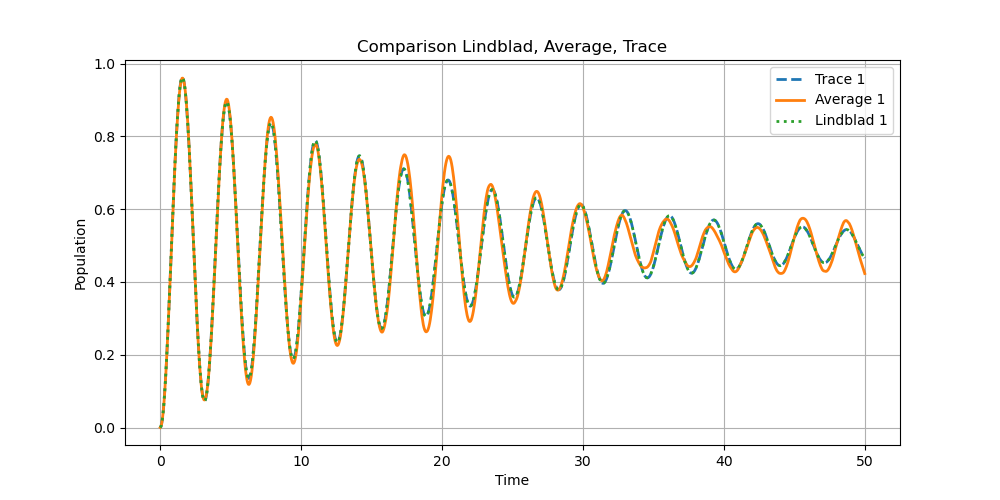

In [66]:
dt = 0.05          # Time step
tf = 50.0          # Final Time
steps = int(tf / dt) # Number of steps
times = np.linspace(0, tf, steps)

fig11, ax = plt.subplots(figsize=(10, 5))

ax.plot(times, pops_1_complete_005[:-1], label=r'Trace 1', linewidth=2, linestyle='--')  # Rimuovi ultimo elemento
ax.plot(times, average_pop_005[0, :], label=r'Average 1', linewidth=2)
ax.plot(times, np.real(rho_list_lindblad_005[:, 2, 2]), label=r'Lindblad 1', linewidth=2, linestyle=':')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title('Comparison Lindblad, Average, Trace')
ax.legend()
ax.grid(True)
plt.show()

# Plot

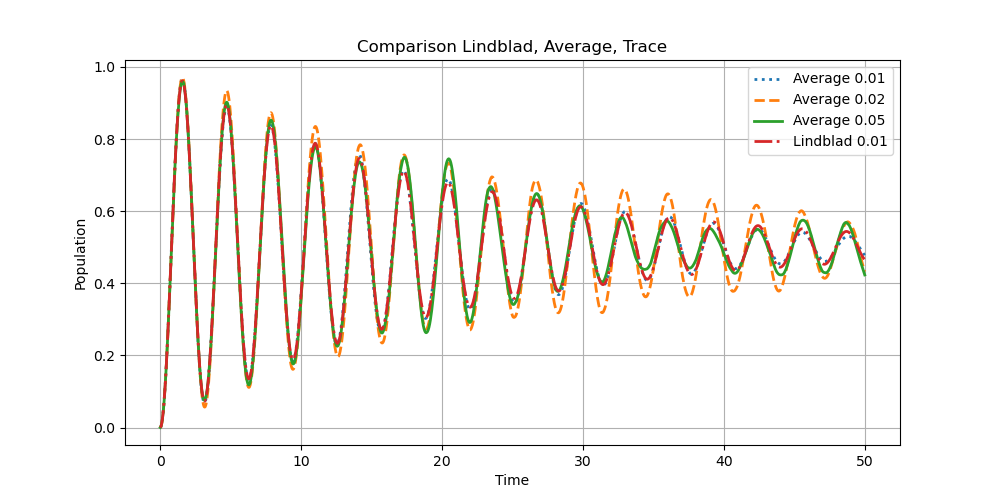

In [67]:
fig12, ax = plt.subplots(figsize=(10, 5))

# Tempi per ogni simulazione
times_001 = np.linspace(0, tf, len(average_pop[0, :]))
times_002 = np.linspace(0, tf, len(average_pop_002[0, :]))
times_005 = np.linspace(0, tf, len(average_pop_005[0, :]))
times_lindblad = np.linspace(0, tf, len(rho_list_lindblad[:, 2, 2]))

ax.plot(times_001, average_pop[0, :], label=r'Average 0.01', linewidth=2, linestyle=':')
ax.plot(times_002, average_pop_002[0, :], label=r'Average 0.02', linewidth=2, linestyle='--')
ax.plot(times_005, average_pop_005[0, :], label=r'Average 0.05', linewidth=2)
ax.plot(times_005, np.real(rho_list_lindblad_005[:, 2, 2]), label=r'Lindblad 0.01', linewidth=2, linestyle='-.')

ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title('Comparison Lindblad, Average, Trace')
ax.legend()
ax.grid(True)
plt.show()